# Artificial Intelligence - Exercise 1
## Football Analysis Exercise
### Kaggle Dataset: International Football Results(1872-2024)

#### Step 1: Load the CSV

In [4]:
import pandas as pd #import the pandas library for data manipulation

In [6]:
df = pd.read_csv("results.csv")
df.head(10)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False
5,1876-03-25,Scotland,Wales,4,0,Friendly,Glasgow,Scotland,False
6,1877-03-03,England,Scotland,1,3,Friendly,London,England,False
7,1877-03-05,Wales,Scotland,0,2,Friendly,Wrexham,Wales,False
8,1878-03-02,Scotland,England,7,2,Friendly,Glasgow,Scotland,False
9,1878-03-23,Scotland,Wales,9,0,Friendly,Glasgow,Scotland,False


### Basic Dataset Exploration

####  Q1: How many matches are in the dataset?

In [7]:
df.shape

(49071, 9)

#### A1: 49071 rows, 9 columns.Thus there 49,071 matches in the dataset

#### Q2: What is the earliest and latest year in the dataset?

In [10]:
print(df["date"].min())
print(df["date"].max())

1872-11-30
2026-01-26


#### A2: The earliest date is 1872-11-30 and the latest date is 2026-01-26

##### Q3: How many unique countries are there?

In [17]:
df["home_team"].nunique()

325

#### A3: There are 325 unique countries in the dataset

#### Q4: Which team appears most frequently as home team?

In [18]:
df["home_team"].value_counts().head()

home_team
Brazil         610
Argentina      599
Mexico         596
Germany        552
South Korea    549
Name: count, dtype: int64

#### A4: Brazil is the most frequently appearing home team(610 times).

### Goals Analysis

In [19]:
df["total_goals"] = df["home_score"] + df["away_score"]

#### Q5: What is the average number of goals per match?

In [32]:
avg_goals_per_match = df["total_goals"].sum() / df.shape[0]
print(f"Average goals per match is : {round(avg_goals_per_match)}")

Average goals per match is : 3


#### Q6: What is the highest scoring match?

In [54]:
max_goals = df["total_goals"].max()
max_index = df['total_goals'].idxmax()
highest_scoring_match_home_team = df.loc[max_index, "home_team"]
highest_scoring_match_away_team = df.loc[max_index, "away_team"]
highest_scoring_match_date = df.loc[max_index,"date"]
print(f"The highest scoring match was between {highest_scoring_match_home_team} and {highest_scoring_match_away_team} whose total goals were {max_goals} and was held on {highest_scoring_match_date}.")


The highest scoring match was between Australia and American Samoa whose total goals were 31 and was held on 2001-04-11.


#### Q7: Are more goals scored home or away?

In [63]:
home_total_goals = df["home_score"].sum()
away_total_goals = df["away_score"].sum()
print(home_total_goals)
print(away_total_goals)
if home_total_goals > away_total_goals :
    print("More goals are scored at home.")
else:
    print("More goals are scored away.")

86182
58011
More goals are scored at home.


##### Q8: What is the most common total goals value?

In [73]:
print(f"The most common total goals value is {df["total_goals"].value_counts().idxmax()} with a total of {df["total_goals"].value_counts().iloc[0]} games.")

The most common total goals value is 2 with a total of 10896 games.


### Match Results

In [78]:
def match_result(row):
    if row["home_score"] > row["away_score"]:
        return "Home Win"
    elif row["home_score"] < row["away_score"]:
        return "Away Win"
    else:
        return "Draw"

df["result"] = df.apply(match_result, axis=1)


##### Q9: What percentage of matches are home wins?

In [110]:
results_groups = df["result"].value_counts()
print(results_groups)
home_wins = results_groups.iloc[0]
print(home_wins)
Total_match_results = df["result"].count()
print(Total_match_results)
home_wins_percentage = (home_wins/Total_match_results) * 100
print(home_wins_percentage)
print(f"Percentage of matches with home wins is {round(home_wins_percentage,2)}%")

result
Home Win    24043
Away Win    13872
Draw        11156
Name: count, dtype: int64
24043
49071
48.996352224328014
Percentage of matches with home wins is 49.0%


#### Q10: Does home advantage exist?

In [127]:
home_wins = results_groups.iloc[0]
print(f"Number of home wins:{home_wins}.")
home_wins_percentage = round((home_wins/Total_match_results) * 100, 2)
print(f"Away wins percentage: {home_wins_percentage}%.")
away_wins = results_groups.iloc[1]
print(f"Number of away wins:{away_wins}.")
away_wins_percentage = round((away_wins/Total_match_results) * 100, 2)
print(f"Away wins percentage: {away_wins_percentage}%.")
draws = results_groups.iloc[2]
print(f"Number of draws :{draws}.")
draws_percentage = round((draws/Total_match_results) * 100, 2)
print(f"Away wins percentage: {draws_percentage}%.")
print("\n")
print(f"Home wins with {home_wins_percentage}%, which is almost half of the total results, indicate that home advantage exists.")

Number of home wins:24043.
Away wins percentage: 49.0%.
Number of away wins:13872.
Away wins percentage: 28.27%.
Number of draws :11156.
Away wins percentage: 22.73%.


Home wins with 49.0%, which is almost half of the total results, indicate that home advantage exists.


#### Q11. Which Country has the most wins historically?

In [128]:
df.head(3)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,total_goals,result
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,0,Draw
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,6,Home Win
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,3,Home Win


In [175]:
def won_team(row):
    if row["home_score"] > row["away_score"]:
        return row["home_team"]
    elif row["home_score"] < row["away_score"]:
        return row["away_team"]
    else:
        return "Draw"

df["Won Team"] = df.apply(won_team,axis = 1)
df.head(3)
Winners = df["Won Team"].value_counts().head(10)
print(Winners)
print("\n")
print(f"{Winners.index[1]} is the country with the most wins historically with a total of {Winners.iloc[1]} wins.")

Won Team
Draw           11156
Brazil           669
England          623
Germany          595
Argentina        586
Sweden           539
South Korea      536
Mexico           510
Italy            474
France           474
Name: count, dtype: int64


Brazil is the country with the most wins historically with a total of 669 wins.


In [150]:
def lost_team(row):
    if row["home_score"] < row["away_score"]:
        return row["home_team"]
    elif row["home_score"] > row["away_score"]:
        return row["away_team"]
    else:
        return "Draw"

df["Lost Team"] = df.apply(lost_team,axis = 1)
df.head(3)
Loosers = df["Lost Team"].value_counts().head()
print(Loosers)
print("\n")
print(f"{Loosers.index[1]} is the country with the most losses historically with a total of {Loosers.iloc[1]} losses.")

Lost Team
Draw                11156
Finland               434
Switzerland           363
Northern Ireland      360
Luxembourg            353
Name: count, dtype: int64


Finland is the country with the most losses hsitorically with a total of 434 losses.


### Visualization

In [152]:
import matplotlib.pyplot as plt

#### Histogram of goals

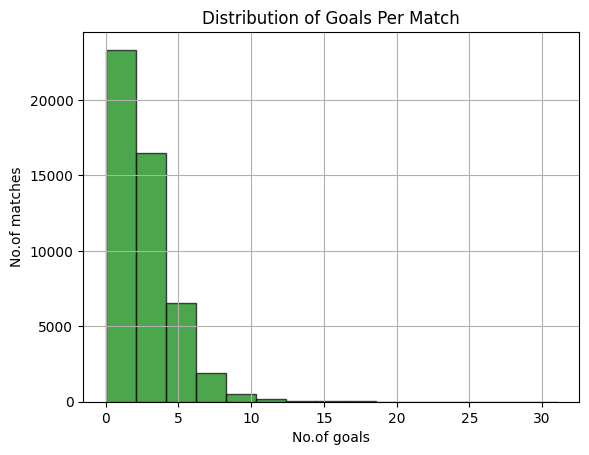

In [159]:
df["total_goals"].hist(bins = 15,color = "green",edgecolor = "black", alpha = 0.7)
plt.title("Distribution of Goals Per Match")
plt.xlabel("No.of goals")
plt.ylabel("No.of matches")
plt.show()

#### Bar Chart of Match Outcomes

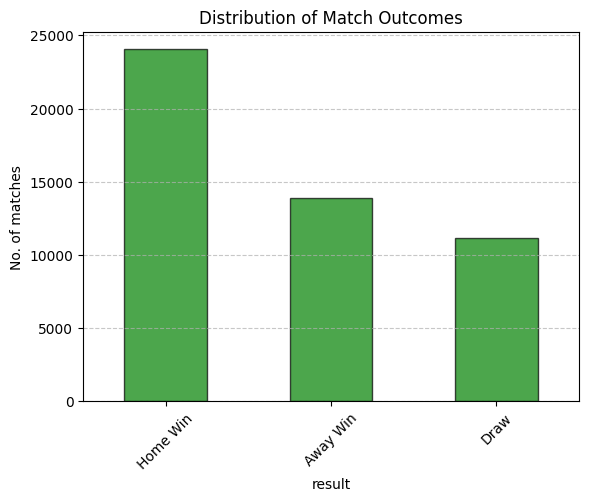

In [182]:
match_outcomes = df["result"].value_counts() 
match_outcomes.plot(kind = "bar", color = "green", edgecolor = "black", alpha=0.7)
plt.title("Distribution of Match Outcomes")
plt.ylabel("No. of matches")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Top 10 teams by total wins

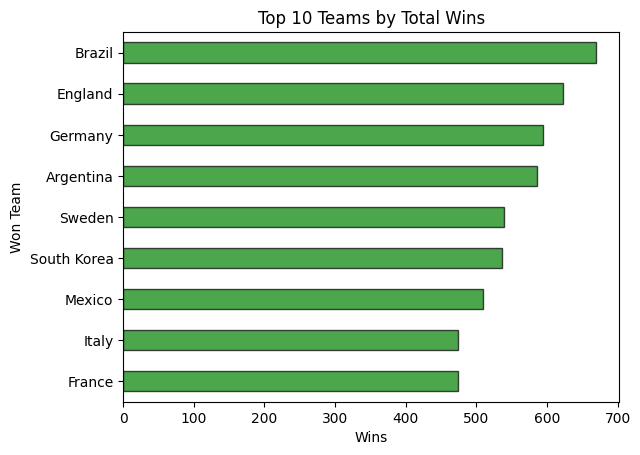

In [180]:
No_draw_only_winners = Winners.iloc[1:]
No_draw_only_winners.plot(kind = "barh",color = "green", edgecolor = "black", alpha = 0.7)
plt.gca().invert_yaxis() 
plt.title("Top 10 Teams by Total Wins")
plt.xlabel("Wins")
plt.show()